# 03 — FinBERT Sentiment Analysis
**P08: Stock Market Sentiment and Price Movement Predictor**

This notebook covers:
1. Loading the **Financial PhraseBank** dataset.
2. Fine-tuning **ProsusAI/finbert** for 3-class sentiment.
3. Evaluating accuracy, precision, recall, and F1 by class.
4. Demonstrating single-sample and batch inference.
5. Running POS analysis with spaCy to compare adjective and verb density across sentiment classes.

---
## 0 · Setup

In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import SEED
from src.sentiment_pipeline import (
    load_phrasebank,
    fine_tune_finbert,
    get_sentiment_score,
    batch_sentiment,
    aggregate_daily_sentiment,
    LABEL_MAP,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})

Device: cpu


---
## 1 · Load Financial PhraseBank

In [3]:
sentences, labels = load_phrasebank()

# Quick look
df_pb = pd.DataFrame({'sentence': sentences, 'label': labels})
df_pb['label_name'] = df_pb['label'].map(LABEL_MAP)
print(f'Dataset size: {len(df_pb)}')
df_pb.head()

[DATA]  Loading Financial PhraseBank (sentences_allagree) …
[DATA]  2264 sentences loaded.  Label distribution: {1: 1391, 2: 570, 0: 303}
Dataset size: 2264


,sentence,label,label_name
0,"According to Gran , the company has no plans t...",1,neutral
1,"For the last quarter of 2010 , Componenta 's n...",2,positive
2,"In the third quarter of 2010 , net sales incre...",2,positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,2,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",2,positive


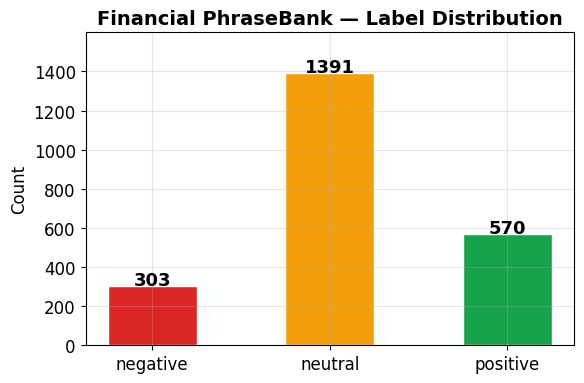

In [4]:
# Label distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_pb['label_name'].value_counts().reindex(['negative', 'neutral', 'positive'])
bars = ax.bar(counts.index, counts.values,
              color=['#dc2626', '#f59e0b', '#16a34a'],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', fontsize=13, fontweight='bold')
ax.set_title('Financial PhraseBank — Label Distribution',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

---
## 2 · Fine-Tune FinBERT

- **Epochs:** 3
- **LR:** 2e-5
- **Batch size:** 16
- Saves to `results/finbert_finetuned/`

In [5]:
model, tokenizer, eval_metrics, history = fine_tune_finbert(
    sentences, labels,
    epochs=3,
    lr=2e-5,
    batch_size=16,
    device=device,
)

[LOAD]  Loading FinBERT from ProsusAI/finbert  (device=cpu)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[SPLIT]  Train 1924 | Eval 340

════════════════════════════════════════════════════════════
  Fine-tuning FinBERT  |  epochs=3  lr=2e-05  batch=16
════════════════════════════════════════════════════════════



  Epoch 1/3  │  Train Loss 0.6777  │  Eval Loss 0.2502  │  Eval Acc 0.9353  ★ best


  Epoch 2/3  │  Train Loss 0.1513  │  Eval Loss 0.1083  │  Eval Acc 0.9765  ★ best


  Epoch 3/3  │  Train Loss 0.0609  │  Eval Loss 0.1172  │  Eval Acc 0.9735

  ✓ Restored best checkpoint (eval_loss=0.1083)

              precision    recall  f1-score   support

    negative       0.95      0.91      0.93        45
     neutral       1.00      1.00      1.00       209
    positive       0.94      0.97      0.95        86

    accuracy                           0.98       340
   macro avg       0.96      0.96      0.96       340
weighted avg       0.98      0.98      0.98       340



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[SAVED]  Fine-tuned model → d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\results\finbert_finetuned


---
## 2b — Load Saved Model (skip retraining)

Run this cell **instead of Section 2** if the model is already trained.

In [6]:
# from transformers import BertForSequenceClassification, BertTokenizer
# SAVE_DIR = 'results/finbert_finetuned'
# tokenizer = BertTokenizer.from_pretrained(SAVE_DIR)
# model     = BertForSequenceClassification.from_pretrained(SAVE_DIR)
# model.to(device)
# model.eval()
# print(f'Loaded fine-tuned model from {SAVE_DIR}')

---
## 3 · Training Loss Curve

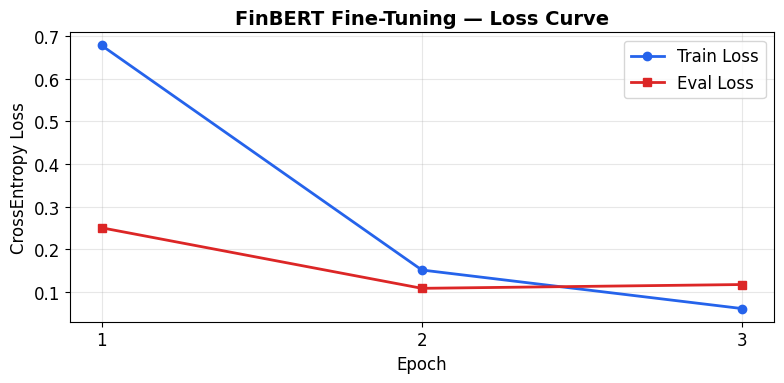

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], marker='o',
        label='Train Loss', color='#2563eb', linewidth=2)
ax.plot(epochs_range, history['eval_loss'], marker='s',
        label='Eval Loss', color='#dc2626', linewidth=2)
ax.set_title('FinBERT Fine-Tuning — Loss Curve',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('CrossEntropy Loss')
ax.set_xticks(list(epochs_range))
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

---
## 4 · Evaluation Metrics

In [8]:
print(f"Accuracy: {eval_metrics['accuracy']:.4f}\n")

metric_df = pd.DataFrame({
    'Class':     ['negative', 'neutral', 'positive'],
    'Precision': [round(p, 4) for p in eval_metrics['precision']],
    'Recall':    [round(r, 4) for r in eval_metrics['recall']],
    'F1-Score':  [round(f, 4) for f in eval_metrics['f1']],
})
metric_df

Accuracy: 0.9765



,Class,Precision,Recall,F1-Score
0,negative,0.9535,0.9111,0.9318
1,neutral,0.9952,0.9952,0.9952
2,positive,0.9432,0.9651,0.9540


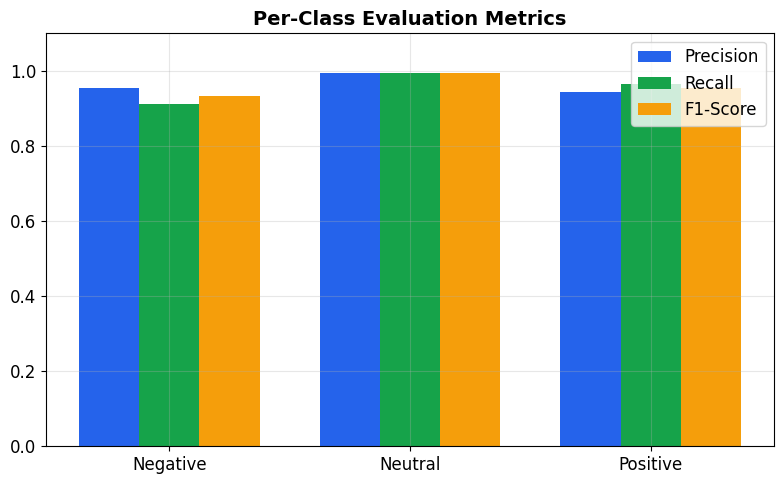

In [9]:
# Grouped bar chart of per-class metrics
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
w = 0.25
ax.bar(x - w, eval_metrics['precision'], w, label='Precision', color='#2563eb')
ax.bar(x,     eval_metrics['recall'],    w, label='Recall',    color='#16a34a')
ax.bar(x + w, eval_metrics['f1'],        w, label='F1-Score',  color='#f59e0b')
ax.set_xticks(x)
ax.set_xticklabels(['Negative', 'Neutral', 'Positive'])
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Evaluation Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

---
## 5 · Single Headline Prediction

In [10]:
test_headlines = [
    "Apple reports record-breaking quarterly revenue",
    "Tesla stock plunges amid delivery concerns",
    "Markets close flat amid mixed economic signals",
    "Amazon faces antitrust scrutiny from regulators",
    "Google Cloud revenue beats analyst expectations",
    "Microsoft announces $10 billion AI investment",
]

for hl in test_headlines:
    result = get_sentiment_score(hl, tokenizer=tokenizer, model=model, device=device)
    print(f"  [{result['sentiment_label']:>8}  {result['sentiment_score']:.3f}]  {hl}")

  [positive  0.877]  Apple reports record-breaking quarterly revenue
  [ neutral  0.731]  Tesla stock plunges amid delivery concerns
  [negative  0.828]  Markets close flat amid mixed economic signals
  [ neutral  0.983]  Amazon faces antitrust scrutiny from regulators
  [positive  0.965]  Google Cloud revenue beats analyst expectations
  [ neutral  0.988]  Microsoft announces $10 billion AI investment


---
## 6 · Batch Inference

In [11]:
batch_df = batch_sentiment(
    test_headlines,
    tokenizer=tokenizer,
    model=model,
    device=device,
)
batch_df

Batch sentiment: 100%|██████████| 1/1 [00:00<00:00, 18.52it/s]


,text,sentiment_label,sentiment_score
0,Apple reports record-breaking quarterly revenue,positive,0.876788
1,Tesla stock plunges amid delivery concerns,neutral,0.730658
2,Markets close flat amid mixed economic signals,negative,0.827984
3,Amazon faces antitrust scrutiny from regulators,neutral,0.982729
4,Google Cloud revenue beats analyst expectations,positive,0.965168
5,Microsoft announces $10 billion AI investment,neutral,0.988343


---
## 7 · Daily Sentiment Aggregation (Demo)

Simulating date-stamped headlines to demonstrate `aggregate_daily_sentiment`.

[AGGREGATE]  95 unique dates, sentiment range [-0.878, 0.855]


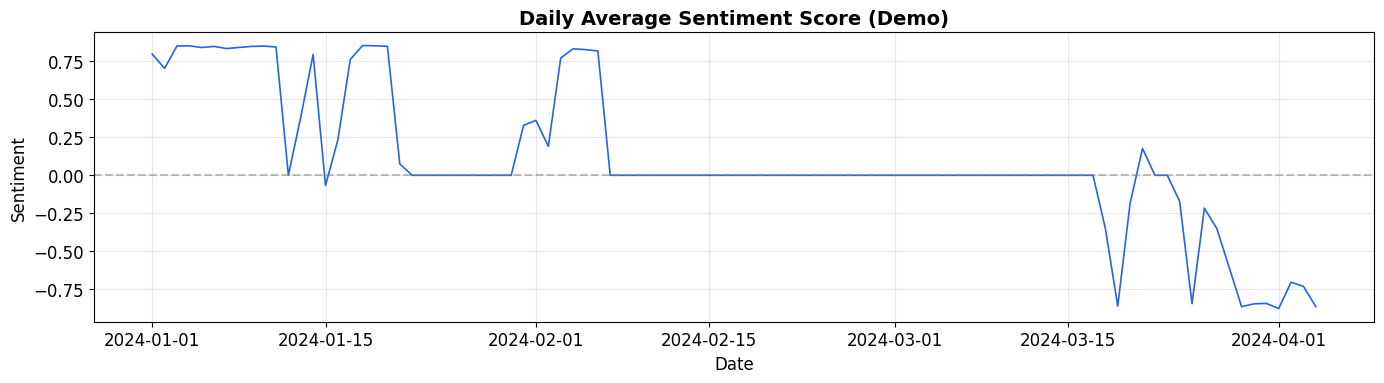

In [12]:
# Create synthetic date-stamped data for demo
np.random.seed(SEED)
demo_dates = pd.date_range('2024-01-01', periods=len(sentences), freq='h')
demo_df = pd.DataFrame({
    'date': demo_dates[:len(sentences)].date,
    'text': sentences,
    'label': labels,
})
demo_df['sentiment_label'] = demo_df['label'].map(LABEL_MAP)
# NOTE: sentiment_score values below are SYNTHETIC (random uniform 0.7–1.0)
# In production, replace with actual scores from batch_sentiment()
demo_df['sentiment_score'] = np.random.uniform(0.7, 1.0, len(demo_df))

daily = aggregate_daily_sentiment(demo_df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['daily_sentiment'], color='#2563eb', linewidth=1.2)
ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax.set_title('Daily Average Sentiment Score (Demo)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sentiment')
plt.tight_layout()
plt.show()

---
## 8 · POS Analysis — Adjective & Verb Density by Sentiment

Using **spaCy** to POS-tag a sample of positive vs negative headlines, then  
comparing adjective density (ADJ / total tokens) and verb density (VERB / total tokens).

In [13]:
import spacy

# Load small English model (download if needed)
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print('Downloading spaCy model en_core_web_sm …')
    spacy.cli.download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

print(f'spaCy model loaded: {nlp.meta["name"]}  ({nlp.meta["version"]})')

spaCy model loaded: core_web_sm  (3.8.0)


In [14]:
# Sample 200 sentences per class for POS analysis
SAMPLE_N = 200

pos_sentences = df_pb[df_pb['label'] == 2]['sentence'].sample(
    n=min(SAMPLE_N, (df_pb['label'] == 2).sum()), random_state=SEED
).tolist()
neg_sentences = df_pb[df_pb['label'] == 0]['sentence'].sample(
    n=min(SAMPLE_N, (df_pb['label'] == 0).sum()), random_state=SEED
).tolist()
neu_sentences = df_pb[df_pb['label'] == 1]['sentence'].sample(
    n=min(SAMPLE_N, (df_pb['label'] == 1).sum()), random_state=SEED
).tolist()

print(f'Sampled — Positive: {len(pos_sentences)}, '
      f'Negative: {len(neg_sentences)}, '
      f'Neutral: {len(neu_sentences)}')

Sampled — Positive: 200, Negative: 200, Neutral: 200


In [15]:
def compute_pos_density(texts, nlp):
    """Compute adjective and verb density for a list of texts."""
    adj_densities = []
    verb_densities = []
    for doc in nlp.pipe(texts, batch_size=64, disable=["parser", "ner"]):
        total = len(doc)
        if total == 0:
            continue
        adj_count  = sum(1 for t in doc if t.pos_ == 'ADJ')
        verb_count = sum(1 for t in doc if t.pos_ == 'VERB')
        adj_densities.append(adj_count / total)
        verb_densities.append(verb_count / total)
    return np.mean(adj_densities), np.mean(verb_densities)

pos_adj, pos_verb = compute_pos_density(pos_sentences, nlp)
neg_adj, neg_verb = compute_pos_density(neg_sentences, nlp)
neu_adj, neu_verb = compute_pos_density(neu_sentences, nlp)

print(f'Positive  →  ADJ: {pos_adj:.4f}  VERB: {pos_verb:.4f}')
print(f'Neutral   →  ADJ: {neu_adj:.4f}  VERB: {neu_verb:.4f}')
print(f'Negative  →  ADJ: {neg_adj:.4f}  VERB: {neg_verb:.4f}')

Positive  →  ADJ: 0.0616  VERB: 0.0836
Neutral   →  ADJ: 0.0561  VERB: 0.0748
Negative  →  ADJ: 0.0626  VERB: 0.0795


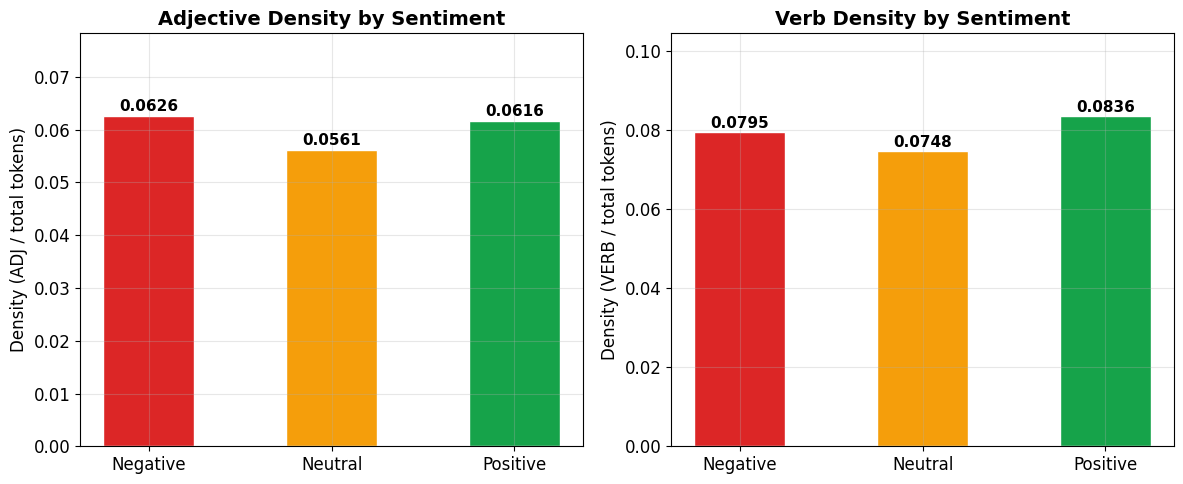

In [16]:
# Bar chart — Adjective & Verb density by sentiment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

classes = ['Negative', 'Neutral', 'Positive']
colors  = ['#dc2626', '#f59e0b', '#16a34a']

# ── Adjective Density ──
adj_vals = [neg_adj, neu_adj, pos_adj]
bars1 = ax1.bar(classes, adj_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars1, adj_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Adjective Density by Sentiment', fontsize=14, fontweight='bold')
ax1.set_ylabel('Density (ADJ / total tokens)')
ax1.set_ylim(0, max(adj_vals) * 1.25)

# ── Verb Density ──
verb_vals = [neg_verb, neu_verb, pos_verb]
bars2 = ax2.bar(classes, verb_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, verb_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Verb Density by Sentiment', fontsize=14, fontweight='bold')
ax2.set_ylabel('Density (VERB / total tokens)')
ax2.set_ylim(0, max(verb_vals) * 1.25)

plt.tight_layout()
plt.show()

---
## 9 · POS Tag Distribution (Detailed)

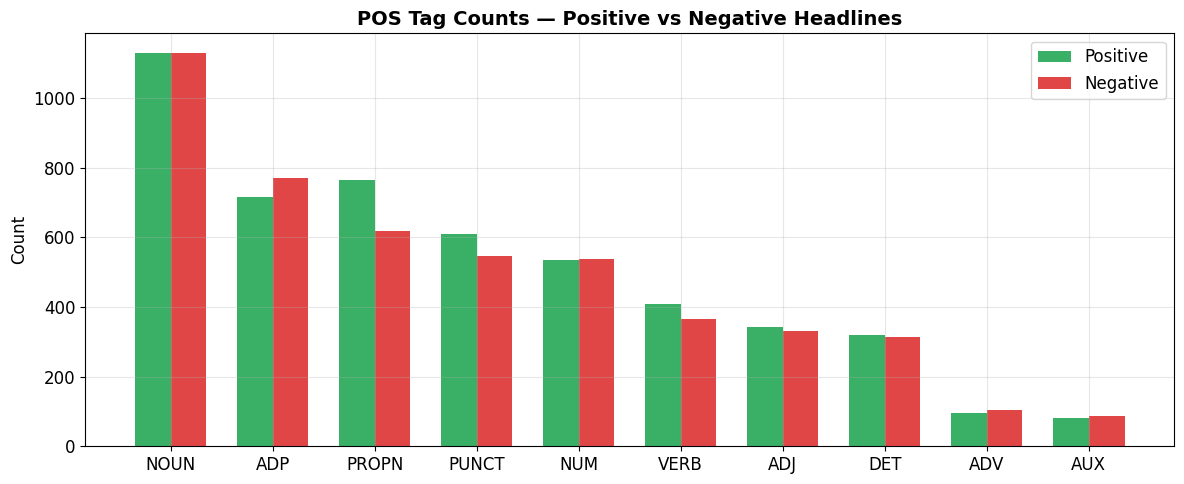

In [17]:
from collections import Counter

def pos_distribution(texts, nlp):
    """Return a Counter of POS tags across all texts."""
    counter = Counter()
    for doc in nlp.pipe(texts, batch_size=64, disable=["parser", "ner"]):
        counter.update(t.pos_ for t in doc)
    return counter

pos_pos  = pos_distribution(pos_sentences, nlp)
neg_pos  = pos_distribution(neg_sentences, nlp)

# Top POS tags
all_tags = sorted(set(pos_pos.keys()) | set(neg_pos.keys()),
                  key=lambda t: pos_pos.get(t, 0) + neg_pos.get(t, 0),
                  reverse=True)[:10]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(all_tags))
w = 0.35
ax.bar(x - w/2, [pos_pos.get(t, 0) for t in all_tags], w,
       label='Positive', color='#16a34a', alpha=0.85)
ax.bar(x + w/2, [neg_pos.get(t, 0) for t in all_tags], w,
       label='Negative', color='#dc2626', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_tags)
ax.set_title('POS Tag Counts — Positive vs Negative Headlines',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

---
### ✅ Fine-tuned model saved to `results/finbert_finetuned/`
### Next Step → `04_fusion_evaluation.ipynb`